In [1]:
import json
import os
from pathlib import Path

import ee
import ee.deserializer
import geemap
import matplotlib.pyplot as plt
import pandas as pd

from nu_afolu.constants import LABEL_LIST

In [2]:
ZONE = "01.1.01"
SETTLEMENT_IDX = LABEL_LIST.index("settlements") + 1

In [3]:
ee.Initialize()

In [4]:
out_path = Path(os.environ["OUT_PATH"])

In [49]:
with (out_path / "bbox" / "ee" / f"{ZONE}.json").open() as f:
    bbox: ee.Geometry = ee.deserializer.decode(json.load(f))

with (out_path / "area_raster" / f"{ZONE}.json").open() as f:
    area_raster: ee.Image = ee.deserializer.decode(json.load(f)).clip(bbox)
    area_raster = area_raster.updateMask(area_raster.neq(ee.Number(0)))

with (out_path / "transition_raster" / f"{ZONE}.json").open() as f:
    transition_raster: ee.Image = ee.deserializer.decode(json.load(f)).clip(bbox)
    transition_raster = transition_raster.updateMask(
        transition_raster.neq(ee.Number(0))
    )

df_area = pd.read_parquet(out_path / "area_table" / f"{ZONE}.parquet")

In [50]:
bbox_buffered = bbox.buffer(10_000)

In [51]:
col_chen = ee.ImageCollection(
    "projects/sat-io/open-datasets/FUTURE-URBAN-LAND/CHEN_2020_2100"
)

ssp_images: dict[str, ee.Image] = {}
for suffix in range(1, 6):
    name = f"SSP{suffix}"
    ssp_images[name] = (
        col_chen.select(name)
        .toBands()
        .rename([str(year) for year in range(2020, 2101, 10)])
        .eq(ee.Number(2))
        .clip(bbox_buffered)
        .selfMask()
    )

In [38]:
settlement_mask = area_raster.eq(ee.Number(SETTLEMENT_IDX))
settlement_mask_resampled = (
    settlement_mask
    .reduceResolution(reducer=ee.Reducer.mean(), maxPixels=2048)
    .reproject(ssp_images["SSP1"].projection())
)

In [64]:
def reduce_ssp_col(col: ee.ImageCollection, *, geometry: ee.Geometry, scale: float) -> pd.DataFrame:
    reduced: ee.FeatureCollection = col.map(
        lambda img: ee.Feature(
            geometry,
            img.eq(ee.Number(2))
            .multiply(ee.Image.pixelArea())
            .reduceRegion(ee.Reducer.sum(), geometry=geometry, scale=scale),
        )
    )

    collected: dict[str, list[float]] = {}
    for suffix in range(1, 6):
        property_name = f"SSP{suffix}"
        arr = reduced.aggregate_array(property_name).getInfo()
        if not isinstance(arr, list):
            err = f"Expected list for property {property_name}, got {type(arr)}"
            raise TypeError(err)
        collected[property_name] = arr

    return pd.DataFrame(collected, index=list(range(2020, 2101, 10)))


df_chen = reduce_ssp_col(col_chen, geometry=bbox, scale=1000)

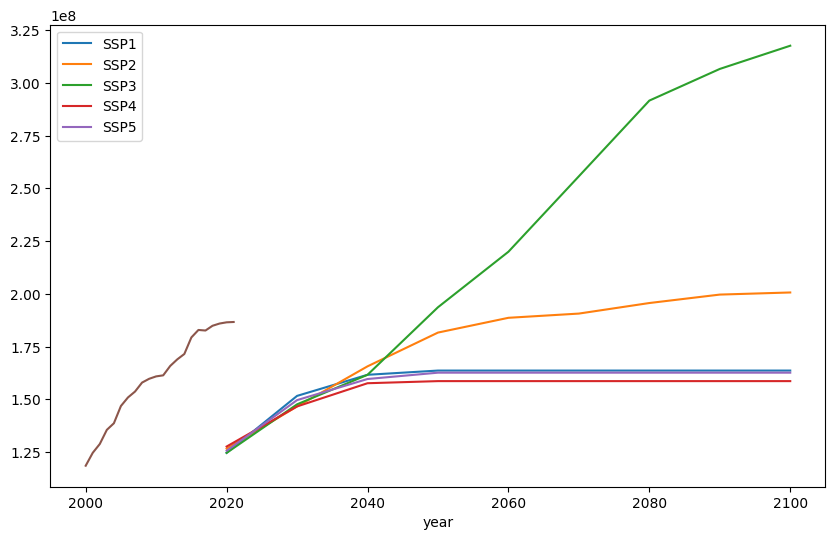

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))
df_chen.plot(ax=ax)
_ = df_area["settlements"].plot(ax=ax)

In [58]:
m = geemap.Map()
m.addLayer(
    settlement_mask_resampled.select("2020").gte(0.4).selfMask(),
    {"min": 0, "max": 1, "palette": "green"},
    "Resampled",
)
m.centerObject(bbox, 11)
m

Map(center=[21.887447862322954, -102.29837192303182], controls=(WidgetControl(options=['position', 'transparen…

In [59]:
m = geemap.Map()
m.addLayer(
    ssp_images["SSP1"],
    {"min": 0, "max": 1, "bands": ["2100"], "palette": "red"},
    "SSP1",
)
m.addLayer(
    settlement_mask.select("2020").selfMask(),
    {"min": 0, "max": 1, "palette": "blue"},
    "Settlements",
)
m.addLayer(
    settlement_mask_resampled.select("2020").gt(0.1).selfMask(),
    {"min": 0, "max": 1, "palette": "green"},
    "Resampled",
)

m.addLayer(bbox)
m.addLayer(bbox_buffered)

m.centerObject(bbox, 11)
m

Map(center=[21.887447862322954, -102.29837192303182], controls=(WidgetControl(options=['position', 'transparen…

In [66]:
source_settlement_area = df_area.loc[2020, "settlements"]
for ssp in df_chen.columns:
    ssp_area = df_chen.loc[2020, ssp]
    print(f"{ssp}: {int(ssp_area):,} m^2 ({ssp_area / source_settlement_area:.2%})")

SSP1: 124,666,666 m^2 (66.84%)
SSP2: 126,666,666 m^2 (67.91%)
SSP3: 124,666,666 m^2 (66.84%)
SSP4: 127,666,666 m^2 (68.44%)
SSP5: 125,666,666 m^2 (67.37%)
